# 02 - Modelado Supervisado
Implementación de múltiples modelos de regresión con Scikit-learn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Agregar ruta de src al path
sys.path.insert(0, r'C:\Users\Arturo\Desktop\Prueba1\src')

# Importar módulos personalizados
from prueba.data_preprocessing import (
    cargar_datos_crudos, 
    crear_features_empleado, 
    preparar_datos_para_ml
)
from prueba.model_training import (
    entrenar_modelos_regresion, 
    obtener_predicciones,
    obtener_features_importance
)

# Configuración
sns.set_theme(style="whitegrid")
seed = 42
np.random.seed(seed)
project_root = r'C:\Users\Arturo\Desktop\Prueba1'

print("Módulos importados exitosamente")

Módulos importados exitosamente


## 1. Carga y Preparación de Datos

In [14]:
# Cargar datos crudos
print("Cargando datos...")
datos_crudos = cargar_datos_crudos(os.path.join(project_root, 'data/01_raw/'))

# Crear dataset consolidado
df_features = crear_features_empleado(datos_crudos)
print(f"Dataset consolidado: {df_features.shape}")
print(f"\nCaracterísticas: {list(df_features.columns)}")

# Preparar datos para ML
print("\nPreparando datos para modelos ML...")
datos_ml = preparar_datos_para_ml(df_features, test_size=0.2, random_state=seed)

X_train = datos_ml['X_train']
X_test = datos_ml['X_test']
y_train = datos_ml['y_train']
y_test = datos_ml['y_test']
feature_names = datos_ml['feature_names']

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Cargando datos...
  Cargado: ausencias (360 filas, 7 columnas)
  Cargado: capacitaciones (412 filas, 8 columnas)
  Cargado: empleados (309 filas, 9 columnas)
  Cargado: evaluaciones (515 filas, 7 columnas)
Dataset consolidado: (309, 16)

Características: ['id_empleado', 'departamento', 'cargo', 'tipo_contrato', 'jornada', 'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia', 'ausencias_justificadas', 'num_capacitaciones', 'total_horas_capacitacion', 'promedio_nota_capacitacion', 'max_nota_capacitacion', 'puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas']

Preparando datos para modelos ML...
X_train: (247, 14)
X_test: (62, 14)
y_train: (247,)
y_test: (62,)


## 2. Entrenamiento de Modelos

In [15]:
print("Entrenando múltiples modelos de regresión...\n")
modelos = entrenar_modelos_regresion(X_train, y_train, random_state=seed)

print(f"\nModelos entrenados:")
for nombre in modelos.keys():
    print(f"  ✓ {nombre}")

# Mostrar puntuaciones en training
print("\nPuntuaciones R² en Training:")
for nombre, modelo in modelos.items():
    score = modelo.score(X_train, y_train)
    print(f"  {nombre}: {score:.4f}")

Entrenando múltiples modelos de regresión...


Modelos entrenados:
  ✓ Linear Regression
  ✓ Ridge
  ✓ Lasso
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ SVR
  ✓ KNN

Puntuaciones R² en Training:
  Linear Regression: 0.0699
  Ridge: 0.0698
  Lasso: 0.0689
  Random Forest: 0.8681
  Gradient Boosting: 0.9999
  SVR: 0.1190
  KNN: 0.2656


## 3. Predicciones en Test

In [16]:
# Obtener predicciones
predicciones_train = obtener_predicciones(modelos, X_train)
predicciones_test = obtener_predicciones(modelos, X_test)

print("Predicciones obtenidas para train y test")
print(f"\nModelos con predicciones:")
for nombre in predicciones_test.keys():
    print(f"  ✓ {nombre} - {len(predicciones_test[nombre])} predicciones")

# Comparar primeras 10 predicciones
print("\nMuestras de predicciones (primeras 10 en test):")
df_comparacion = pd.DataFrame({'y_real': y_test.iloc[:10].values})

for nombre, pred in predicciones_test.items():
    df_comparacion[f'{nombre}'] = pred[:10]
    df_comparacion[f'{nombre}_error'] = np.abs(pred[:10] - df_comparacion['y_real'].values)

print(df_comparacion.head(10))

Predicciones obtenidas para train y test

Modelos con predicciones:
  ✓ Linear Regression - 62 predicciones
  ✓ Ridge - 62 predicciones
  ✓ Lasso - 62 predicciones
  ✓ Random Forest - 62 predicciones
  ✓ Gradient Boosting - 62 predicciones
  ✓ SVR - 62 predicciones
  ✓ KNN - 62 predicciones

Muestras de predicciones (primeras 10 en test):
   y_real  Linear Regression  Linear Regression_error      Ridge  Ridge_error  \
0    19.0          -0.069949                19.069949   0.530318    18.469682   
1     5.3           5.791442                 0.491442   6.499158     1.199158   
2     3.7           3.507508                 0.192492   3.539406     0.160594   
3     4.2          10.907236                 6.707236  10.848797     6.648797   
4     4.8           4.294477                 0.505523   5.449240     0.649240   
5     0.0          -2.709759                 2.709759  -2.885109     2.885109   
6     6.5          16.703448                10.203448  16.920183    10.420183   
7     3.3  

## 4. Visualización de Predicciones vs Reales

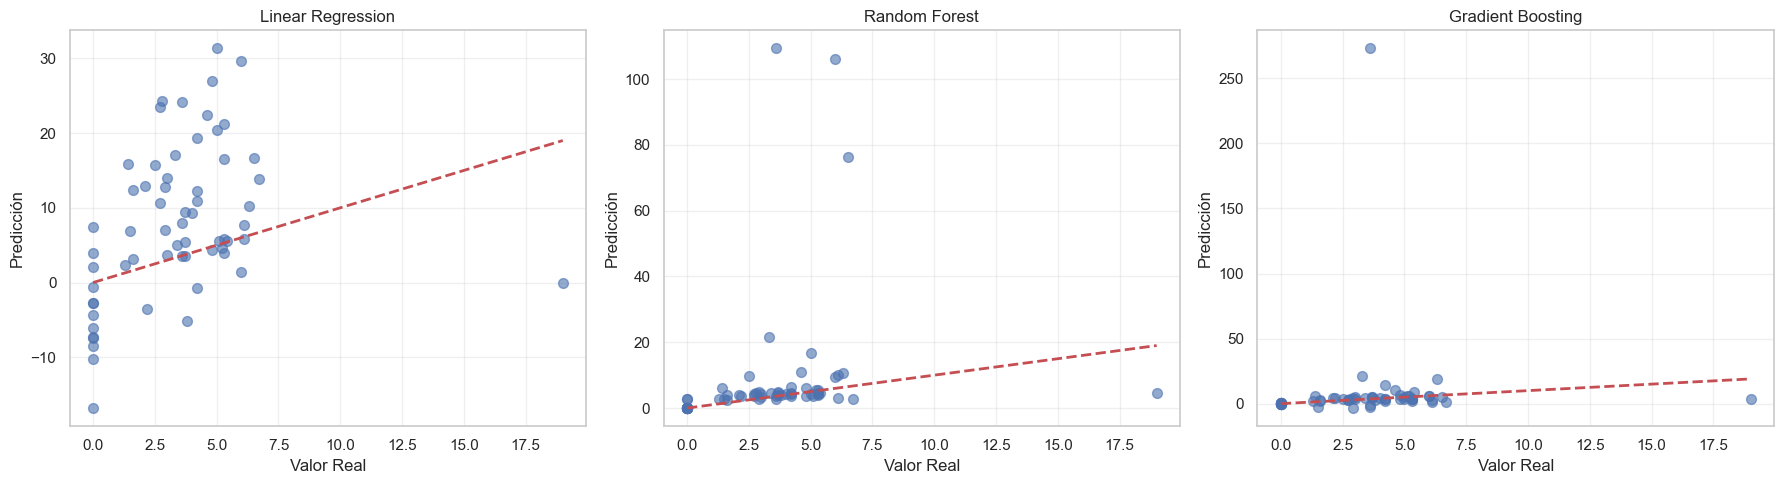

Gráfico guardado


In [11]:
# Graficar predicciones vs reales para los 3 mejores modelos
modelos_graficar = ['Linear Regression', 'Random Forest', 'Gradient Boosting']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nombre_modelo in enumerate(modelos_graficar):
    pred = predicciones_test[nombre_modelo]
    
    axes[idx].scatter(y_test, pred, alpha=0.6, s=50)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_xlabel('Valor Real')
    axes[idx].set_ylabel('Predicción')
    axes[idx].set_title(f'{nombre_modelo}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/04_predicciones_vs_reales.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado")

## 5. Importancia de Features (Modelos basados en árboles)

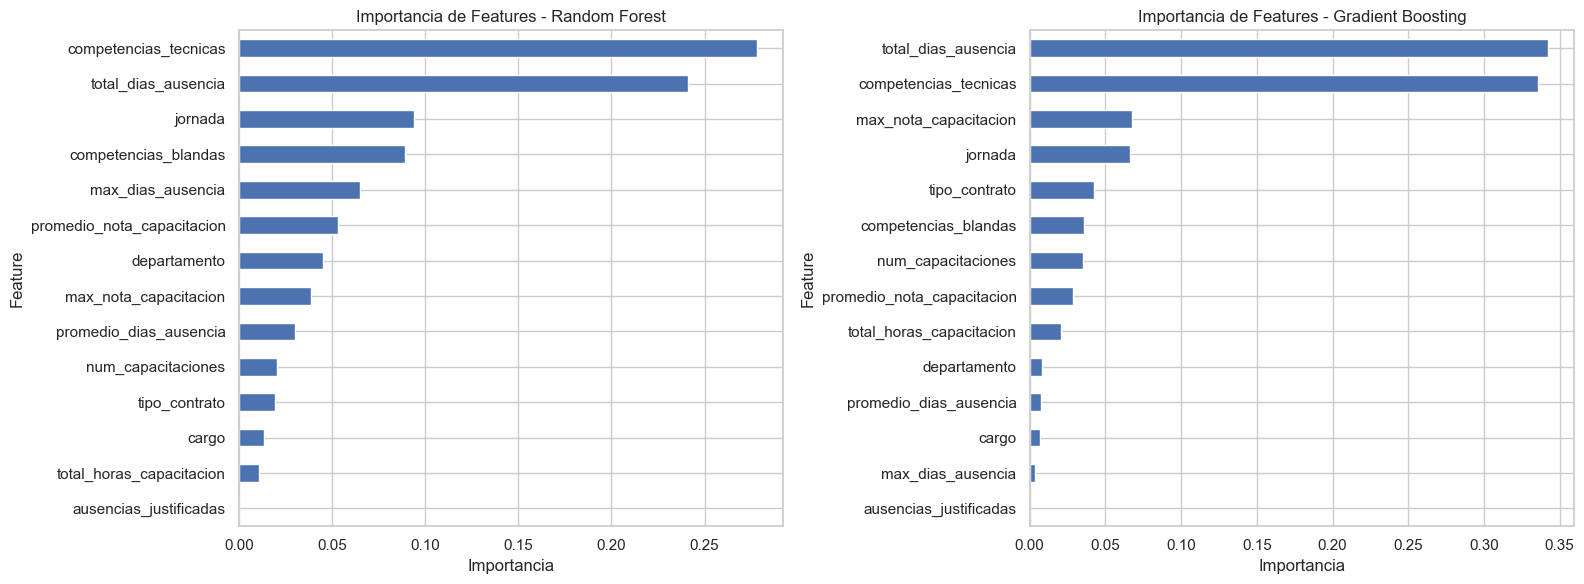

Gráfico de importancia guardado


In [17]:
# Obtener importancia de features
importance_dict = obtener_features_importance(modelos)

if importance_dict:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, (nombre_modelo, importances) in enumerate(importance_dict.items()):
        # Crear dataframe con importancias
        df_imp = pd.DataFrame({
            'Feature': feature_names,
            'Importancia': importances
        }).sort_values('Importancia', ascending=True)
        
        # Graficar
        df_imp.plot(kind='barh', x='Feature', y='Importancia', ax=axes[idx], legend=False)
        axes[idx].set_title(f'Importancia de Features - {nombre_modelo}')
        axes[idx].set_xlabel('Importancia')
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/05_feature_importance.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Gráfico de importancia guardado")
else:
    print("No hay modelos con feature importance")

## 6. Resumen de Modelos

In [18]:
print("="*70)
print("RESUMEN DE MODELOS SUPERVISADOS ENTRENADOS")
print("="*70)

resumen = []
for nombre, modelo in modelos.items():
    r2_train = modelo.score(X_train, y_train)
    r2_test = modelo.score(X_test, y_test)
    
    resumen.append({
        'Modelo': nombre,
        'R² Train': r2_train,
        'R² Test': r2_test,
        'Diferencia': r2_train - r2_test
    })

df_resumen = pd.DataFrame(resumen).sort_values('R² Test', ascending=False)
print(df_resumen.to_string(index=False))
print("\nMejor modelo en Test:", df_resumen.iloc[0]['Modelo'])

# Guardar resumen
df_resumen.to_csv(os.path.join(project_root, 'results/metrics/02_resumen_modelos.csv'), index=False)
print(f"\nResumen guardado en results/metrics/02_resumen_modelos.csv")

RESUMEN DE MODELOS SUPERVISADOS ENTRENADOS
           Modelo  R² Train     R² Test  Diferencia
              SVR  0.119036   -1.245595    1.364631
            Lasso  0.068914  -10.919583   10.988497
            Ridge  0.069783  -12.006578   12.076362
Linear Regression  0.069923  -12.563918   12.633841
              KNN  0.265565  -34.400918   34.666483
    Random Forest  0.868105  -51.527273   52.395378
Gradient Boosting  0.999884 -142.478653  143.478536

Mejor modelo en Test: SVR

Resumen guardado en results/metrics/02_resumen_modelos.csv
